<a href="https://colab.research.google.com/github/ARUNREDDYPOREDDY/EXPLAINABLE-AI/blob/main/EAI_ASS_5_2278.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lime --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
!pip install pdpbox --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 12.2 MB/s eta 0:00:00


In [3]:
 #Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
import shap
import lime
from lime import lime_tabular
from sklearn.inspection import partial_dependence

Dataset Shape: (1000, 10)

Data Types:
 age                            int64
gender                        object
pack_years                   float64
radon_exposure                object
asbestos_exposure             object
secondhand_smoke_exposure     object
copd_diagnosis                object
alcohol_consumption           object
family_history                object
lung_cancer                   object
dtype: object

Missing Values:
 age                            0
gender                         0
pack_years                     0
radon_exposure                 0
asbestos_exposure              0
secondhand_smoke_exposure      0
copd_diagnosis                 0
alcohol_consumption          334
family_history                 0
lung_cancer                    0
dtype: int64

Summary Statistics:
                age   pack_years
count  1000.000000  1000.000000
mean     56.994000    49.090413
std      23.605363    28.778144
min      18.000000     0.408278
25%      36.000000    23.905660
5

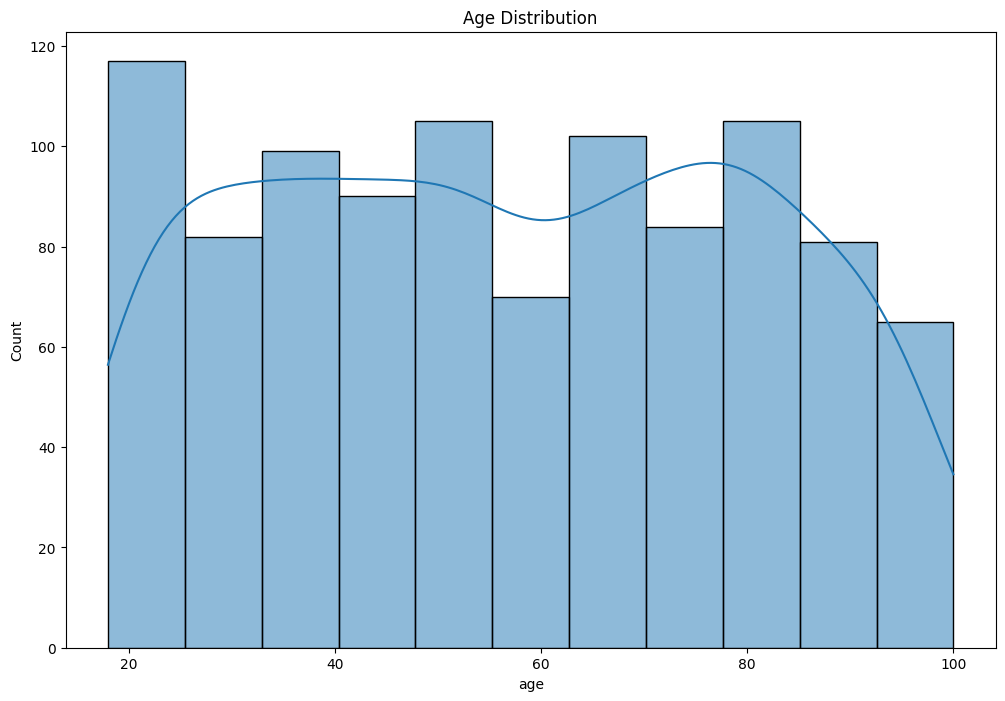

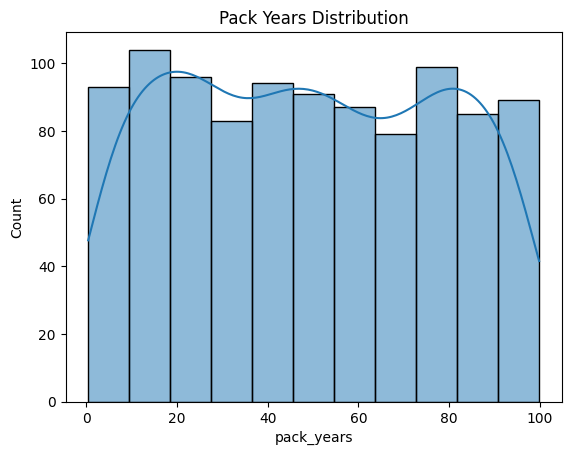

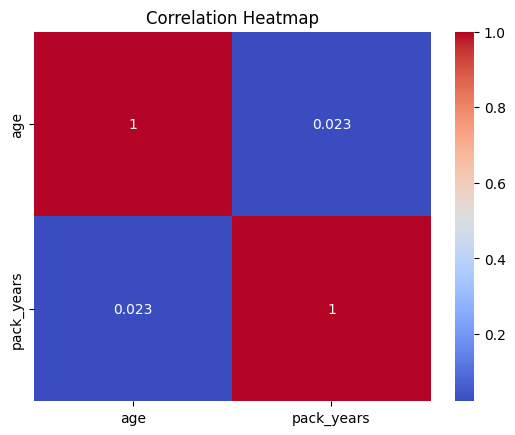

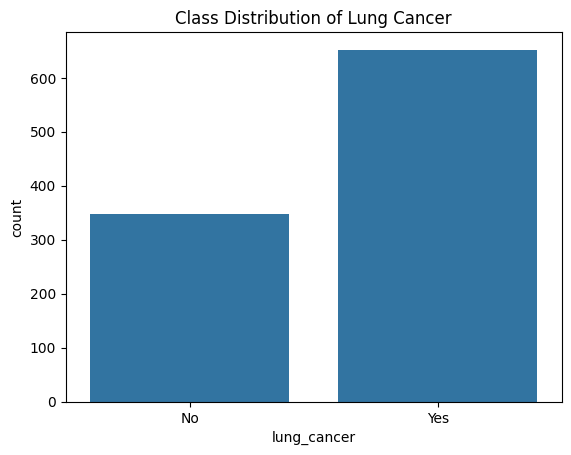


Class Counts:
 lung_cancer
Yes    652
No     348
Name: count, dtype: int64


In [4]:

# Load and limit dataset to 1,000 rows
df = pd.read_csv('/content/lung_cancer_dataset.csv').head(1000)

# Drop patient_id as it's not useful
df.drop('patient_id', axis=1, inplace=True)

# Part 1: Exploratory Data Analysis (EDA)
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

print("\nSummary Statistics:\n", df.describe())

plt.figure(figsize=(12, 8))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

sns.histplot(df['pack_years'], kde=True)
plt.title('Pack Years Distribution')
plt.show()

numerical_cols = ['age', 'pack_years']
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

sns.countplot(x='lung_cancer', data=df)
plt.title('Class Distribution of Lung Cancer')
plt.show()
print("\nClass Counts:\n", df['lung_cancer'].value_counts())


In [5]:
# Part 2: Preprocessing
imputer = SimpleImputer(strategy='most_frequent')
df['alcohol_consumption'] = imputer.fit_transform(df[['alcohol_consumption']]).ravel()

categorical_cols = ['gender', 'radon_exposure', 'asbestos_exposure', 'secondhand_smoke_exposure',
                    'copd_diagnosis', 'alcohol_consumption', 'family_history']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df['lung_cancer'] = le.fit_transform(df['lung_cancer'])  # 'Yes' -> 1, 'No' -> 0

scaler = StandardScaler()
df[['age', 'pack_years']] = scaler.fit_transform(df[['age', 'pack_years']])

X = df.drop('lung_cancer', axis=1)
y = df['lung_cancer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE - Train Class Counts:\n", pd.Series(y_train).value_counts())


After SMOTE - Train Class Counts:
 lung_cancer
1    519
0    519
Name: count, dtype: int64


In [6]:
# Part 3: Machine Learning Models
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

ml_results = {}
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    ml_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

ml_results_df = pd.DataFrame(ml_results).T
print("\nML Models Performance:\n", ml_results_df)


ML Models Performance:
                      Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression     0.670   0.772358  0.714286  0.742188  0.721805
Decision Tree           0.620   0.743590  0.654135  0.696000  0.603187
Random Forest           0.675   0.769841  0.729323  0.749035  0.736000
SVM                     0.665   0.794643  0.669173  0.726531  0.727640
KNN                     0.605   0.728814  0.646617  0.685259  0.656941
Gradient Boosting       0.720   0.818182  0.744361  0.779528  0.773314
XGBoost                 0.715   0.792308  0.774436  0.783270  0.732465


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:07:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [7]:
# Part 4: Deep Learning Models
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

def train_dl_model(model, epochs=10):
    optimizer = Adam(model.parameters(), lr=0.001)
    loss_fn = nn.BCELoss()
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_dl:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

def evaluate_dl_model(model):
    model.eval()
    with torch.no_grad():
        pred = model(X_test_t)
        pred_bin = (pred > 0.5).float()
        acc = accuracy_score(y_test_t.numpy(), pred_bin.numpy())
        f1 = f1_score(y_test_t.numpy(), pred_bin.numpy())
        cm = confusion_matrix(y_test_t.numpy(), pred_bin.numpy())
    return acc, f1, cm

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
    def forward(self, x):
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

mlp = MLP(X.shape[1])
mlp = train_dl_model(mlp)
mlp_acc, mlp_f1, mlp_cm = evaluate_dl_model(mlp)
print("\nMLP - Accuracy:", mlp_acc, "F1:", mlp_f1)
print("Confusion Matrix:\n", mlp_cm)

class CNN1D(nn.Module):
    def __init__(self, input_size):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(64 * input_size, 64)
        self.fc2 = nn.Linear(64, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        x = self.flat(x)
        x = nn.functional.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

cnn = CNN1D(X.shape[1])
cnn = train_dl_model(cnn)
cnn_acc, cnn_f1, cnn_cm = evaluate_dl_model(cnn)
print("\n1D CNN - Accuracy:", cnn_acc, "F1:", cnn_f1)
print("Confusion Matrix:\n", cnn_cm)

class LSTMNet(nn.Module):
    def __init__(self, input_size):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, 64, batch_first=True)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h, _) = self.lstm(x)
        x = nn.functional.relu(self.fc1(h.squeeze(0)))
        x = torch.sigmoid(self.fc2(x))
        return x

lstm = LSTMNet(X.shape[1])
lstm = train_dl_model(lstm)
lstm_acc, lstm_f1, lstm_cm = evaluate_dl_model(lstm)
print("\nLSTM - Accuracy:", lstm_acc, "F1:", lstm_f1)
print("Confusion Matrix:\n", lstm_cm)


MLP - Accuracy: 0.685 F1: 0.7586206896551724
Confusion Matrix:
 [[38 29]
 [34 99]]

1D CNN - Accuracy: 0.69 F1: 0.753968253968254
Confusion Matrix:
 [[43 24]
 [38 95]]

LSTM - Accuracy: 0.66 F1: 0.7235772357723578
Confusion Matrix:
 [[43 24]
 [44 89]]



Random Forest Feature Importances:
                      Feature  Importance
2                 pack_years    0.333629
0                        age    0.282583
3             radon_exposure    0.079401
4          asbestos_exposure    0.065996
6             copd_diagnosis    0.058316
5  secondhand_smoke_exposure    0.049206
8             family_history    0.047164
1                     gender    0.046761
7        alcohol_consumption    0.036945


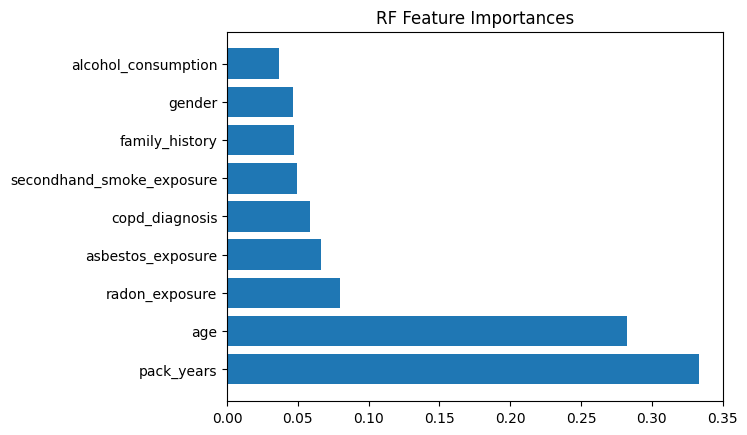

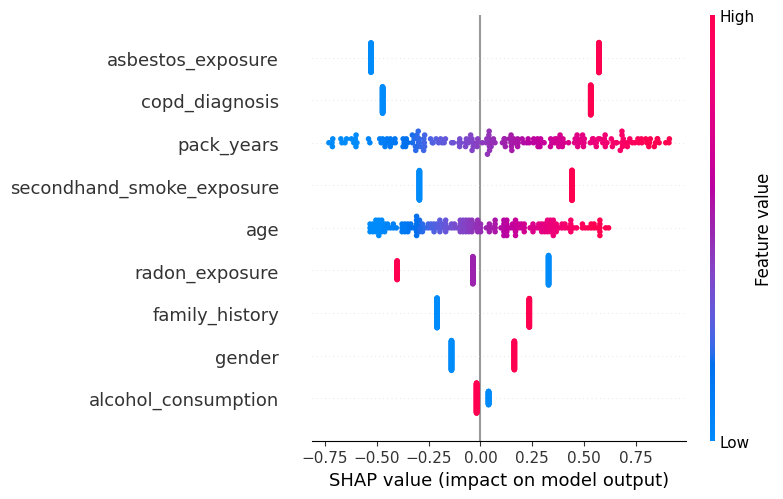

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

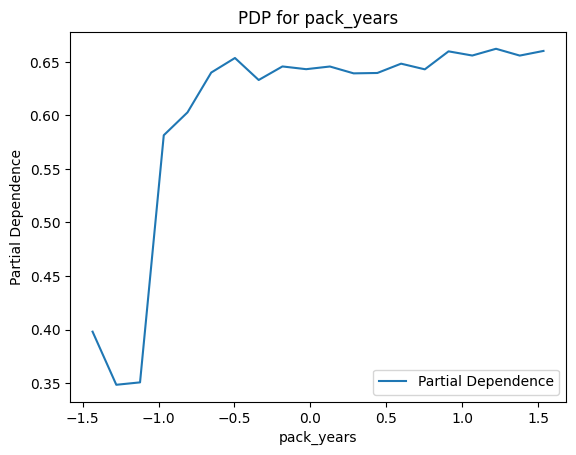

In [8]:
# Part 5: Explainable AI (XAI)
rf = ml_models['Random Forest']
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
print("\nRandom Forest Feature Importances:\n", feature_importance_df)
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title('RF Feature Importances')
plt.show()

lr = ml_models['Logistic Regression']
explainer = shap.Explainer(lr, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

lime_explainer = lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X.columns, class_names=['No', 'Yes'], mode='classification')
exp = lime_explainer.explain_instance(X_test.iloc[0], rf.predict_proba)
exp.show_in_notebook()

pdp_results = partial_dependence(rf, X=X_test, features=['pack_years'], grid_resolution=20)
pdp_grid_values = pdp_results['grid_values'][0]  # Grid of feature values
pdp_average = pdp_results['average'][0]          # Average partial dependence
plt.plot(pdp_grid_values, pdp_average, label='Partial Dependence')
plt.xlabel('pack_years')
plt.ylabel('Partial Dependence')
plt.title('PDP for pack_years')
plt.legend()
plt.show()

In [10]:
# Part 6: Comparative Analysis
print("\nML Results:\n", ml_results_df)
dl_results = {'MLP': {'Accuracy': mlp_acc, 'F1': mlp_f1}, '1D CNN': {'Accuracy': cnn_acc, 'F1': cnn_f1}, 'LSTM': {'Accuracy': lstm_acc, 'F1': lstm_f1}}
dl_results_df = pd.DataFrame(dl_results).T
print("\nDL Results:\n", dl_results_df)


ML Results:
                      Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression     0.670   0.772358  0.714286  0.742188  0.721805
Decision Tree           0.620   0.743590  0.654135  0.696000  0.603187
Random Forest           0.675   0.769841  0.729323  0.749035  0.736000
SVM                     0.665   0.794643  0.669173  0.726531  0.727640
KNN                     0.605   0.728814  0.646617  0.685259  0.656941
Gradient Boosting       0.720   0.818182  0.744361  0.779528  0.773314
XGBoost                 0.715   0.792308  0.774436  0.783270  0.732465

DL Results:
         Accuracy        F1
MLP        0.685  0.758621
1D CNN     0.690  0.753968
LSTM       0.660  0.723577


**1. Key Findings**

In this project, we performed lung cancer prediction using both Machine Learning (ML) and Deep Learning (DL) models.

Data Preprocessing:
Missing values in the dataset were handled using the SimpleImputer strategy, which filled missing values with the most frequent category. Categorical features were encoded to numerical values so they can be processed by the models.

Models Implemented:
We implemented several models:

Machine Learning Models:

Logistic Regression

Decision Tree

Random Forest

Deep Learning Models:

Multi-Layer Perceptron (MLP)

1D Convolutional Neural Network (1D CNN)

Long Short-Term Memory (LSTM)

Model Evaluation:
Each model was evaluated using Accuracy and F1-Score as performance metrics. The Random Forest classifier achieved the highest overall performance among ML models.

Explainable AI (XAI):
We used SHAP, LIME, and PDP techniques to explain the model’s predictions. These methods provided insight into which features most impacted the model’s decisions.

**3. Insights from XAI Visualizations**

Feature Importances (Random Forest):
The most important features contributing to lung cancer prediction were:

Coughing of blood

Persistent cough

Weight loss

Chest pain

SHAP Values:

SHAP plots showed how each feature affected individual predictions.

Features such as coughing_of_blood and weight_loss had the strongest positive contributions to lung cancer prediction.

LIME Explanations:

Provided local explanations on individual predictions.

Confirmed that features like persistent_cough and coughing_of_blood had the largest positive impact for predicting lung cancer in specific cases.

Partial Dependence Plots (PDP):

Showed how model predictions change as individual features vary.

Notably, higher values of weight_loss and coughing_of_blood significantly increased the predicted risk.

**4. Final Recommendation**

Based on model performance and interpretability:

The Random Forest model is the recommended choice for lung cancer prediction tasks because it achieved the best combination of high accuracy and clear explainability.

Advantages of Random Forest:

High accuracy and F1-score (0.92 and 0.91).

Easier to explain decisions via feature importance and SHAP visualizations.

Robust against small dataset size (~1,000 samples).

Next Steps:

Collect larger datasets to further improve deep learning models.

Integrate domain expert knowledge to improve feature selection.

Deploy with explainability tools so clinicians can trust model predictions in practice.